In [54]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go #
from plotly.subplots import make_subplots

In [55]:
rng = np.random.default_rng(42)
rng

# np → the NumPy library (usually imported as import numpy as np)
# random.default_rng(...) → creates a random number generator object
# 42 → the seed

Generator(PCG64) at 0x7B8FA8AFFD80

In [56]:
patient_data = pd.DataFrame({
    "age": rng.integers(18,90,300),
    "treatment_duration" : rng.gamma(2.0,5.0,300).astype(int).clip(1,None),
    "recovery_rate":np.clip(np.round(rng.normal(0.85,0.08,300),2),0.4,1.0)
})

# Generates values from a gamma distribution (good choice for durations)
# astype(int) → converts to whole numbers
# clip(1, None) → ensures minimum duration is 1 (no zeros or negatives)

patient_data

,age,treatment_duration,recovery_rate
0,24,17,0.72
1,73,7,0.67
2,65,1,0.93
3,49,7,0.95
4,49,9,0.77
...,...,...,...
295,55,2,0.89
296,79,11,0.81
297,49,12,0.85
298,38,10,0.93


In [57]:
geo_data = pd.DataFrame({
    "state":["CA","TX","NY","FL","IL","PA","OH","GA","NC","MI"],
    "case_rate":np.round(rng.uniform(100,2000,10),2)
})
geo_data

,state,case_rate
0,CA,1878.28
1,TX,1722.57
2,NY,712.21
3,FL,1134.64
4,IL,1030.67
5,PA,1301.18
6,OH,734.81
7,GA,563.99
8,NC,1834.08
9,MI,1855.36


In [58]:
fig = make_subplots(
    rows =2 , cols = 2,
    subplot_titles = ("Patient Age Distribution","Treatment Outcomes", "Geographic Spread","Resource Utilization"),
    specs=[
        [{'type':'bar'},{'type':'scatter'}],
        [{'type':'geo'},{'type':'pie'}]
        ]
)

In [59]:
fig.add_trace(go.Histogram(x=patient_data['age'], name="Age",showlegend=False), row=1, col=1)

In [60]:
fig.add_trace(go.Scatter(x=patient_data['treatment_duration'],y=patient_data["recovery_rate"],mode='markers',name="Outcomes",showlegend=False), row=1, col=2)

In [61]:
fig.add_trace(
    go.Choropleth(
        locations=geo_data["state"],
        z = geo_data['case_rate'],
        locationmode="USA-states",
        colorscale="Plasma",
        colorbar=dict(title="Cases/ 100k", x=0.44, xanchor="left",
        y=0.03,
        yanchor="bottom",
        len = 0.4,
        thickness=12
    )),
    row=2, col=1
)

In [62]:
fig.add_trace(go.Pie(labels=["ICU","General","Emergency","Outpatient"],
                     values = [30,40,15,15],
                     showlegend=False, textinfo="percent+label"), row= 2, col = 2)

In [63]:
fig.update_xaxes (title_text="Age (years)", row=1, col=1)
fig.update_yaxes (title_text="Number of Patients", row=1, col=1)
fig.update_xaxes (title_text="Treatment Duration (days)", row=1, col=2)
fig.update_yaxes (title_text="Recovery Rate", row=1, col=2)
fig.update_geos(scope='usa', row=2, col=1)

fig.update_layout(title="Healthcare Analytics Dashboard", height=800,
margin=dict(t=90, r=20, l=20, b=20)
)
fig.show()


## Step 1: Import Required Libraries

In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

## Step 2: Set Visualization Style

In [65]:
sns.set_theme(style="whitegrid")

## Step 3: Generate Simulated Data

In [66]:
# Customer Data
np.random.seed(42)
num_records = 400

customer_data = pd.DataFrame({
    'age_group': np.random.choice(['18-24', '25-44', '45-64', '65+'], num_records),
    'frequency': np.random.randint(1, 20, num_records),
    'monetary_value': np.random.uniform(50, 2000, num_records)
})

customer_data['customer_segment'] = pd.cut(customer_data['monetary_value'],
                                          bins=[0, 500, 1500, np.inf],
                                          labels=['Low', 'Mid', 'High'],
                                          right=False)

# Sales Data
start_date = pd.to_datetime('2025-01-01')
dates = pd.date_range(start=start_date, periods=120, freq='D')
revenue = np.cumsum(np.random.uniform(100, 500, 120)) + np.linspace(0, 10000, 120) # Cumulative increasing trend
sales_data = pd.DataFrame({
    'Date': dates,
    'Revenue': revenue
})

# Product Data
product_categories = ['Electronics', 'Clothing', 'Home', 'Toys']
product_data = pd.DataFrame({
    'Category': product_categories,
    'Sales': np.random.randint(5000, 25000, len(product_categories))
})

# Social Media Data
platforms = ['Twitter', 'Instagram', 'Facebook']
content_types = ['Video', 'Image', 'Text']

social_media_data = pd.DataFrame({
    'Platform': np.random.choice(platforms, 30),
    'Content_Type': np.random.choice(content_types, 30),
    'Engagement_Rate': np.random.uniform(0.01, 0.15, 30)
})

## Step 4: Create Subplots Layout and Step 5: Create Visualizations

/tmp/ipykernel_24098/3306274182.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_24098/3306274182.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_24098/3306274182.py:39: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




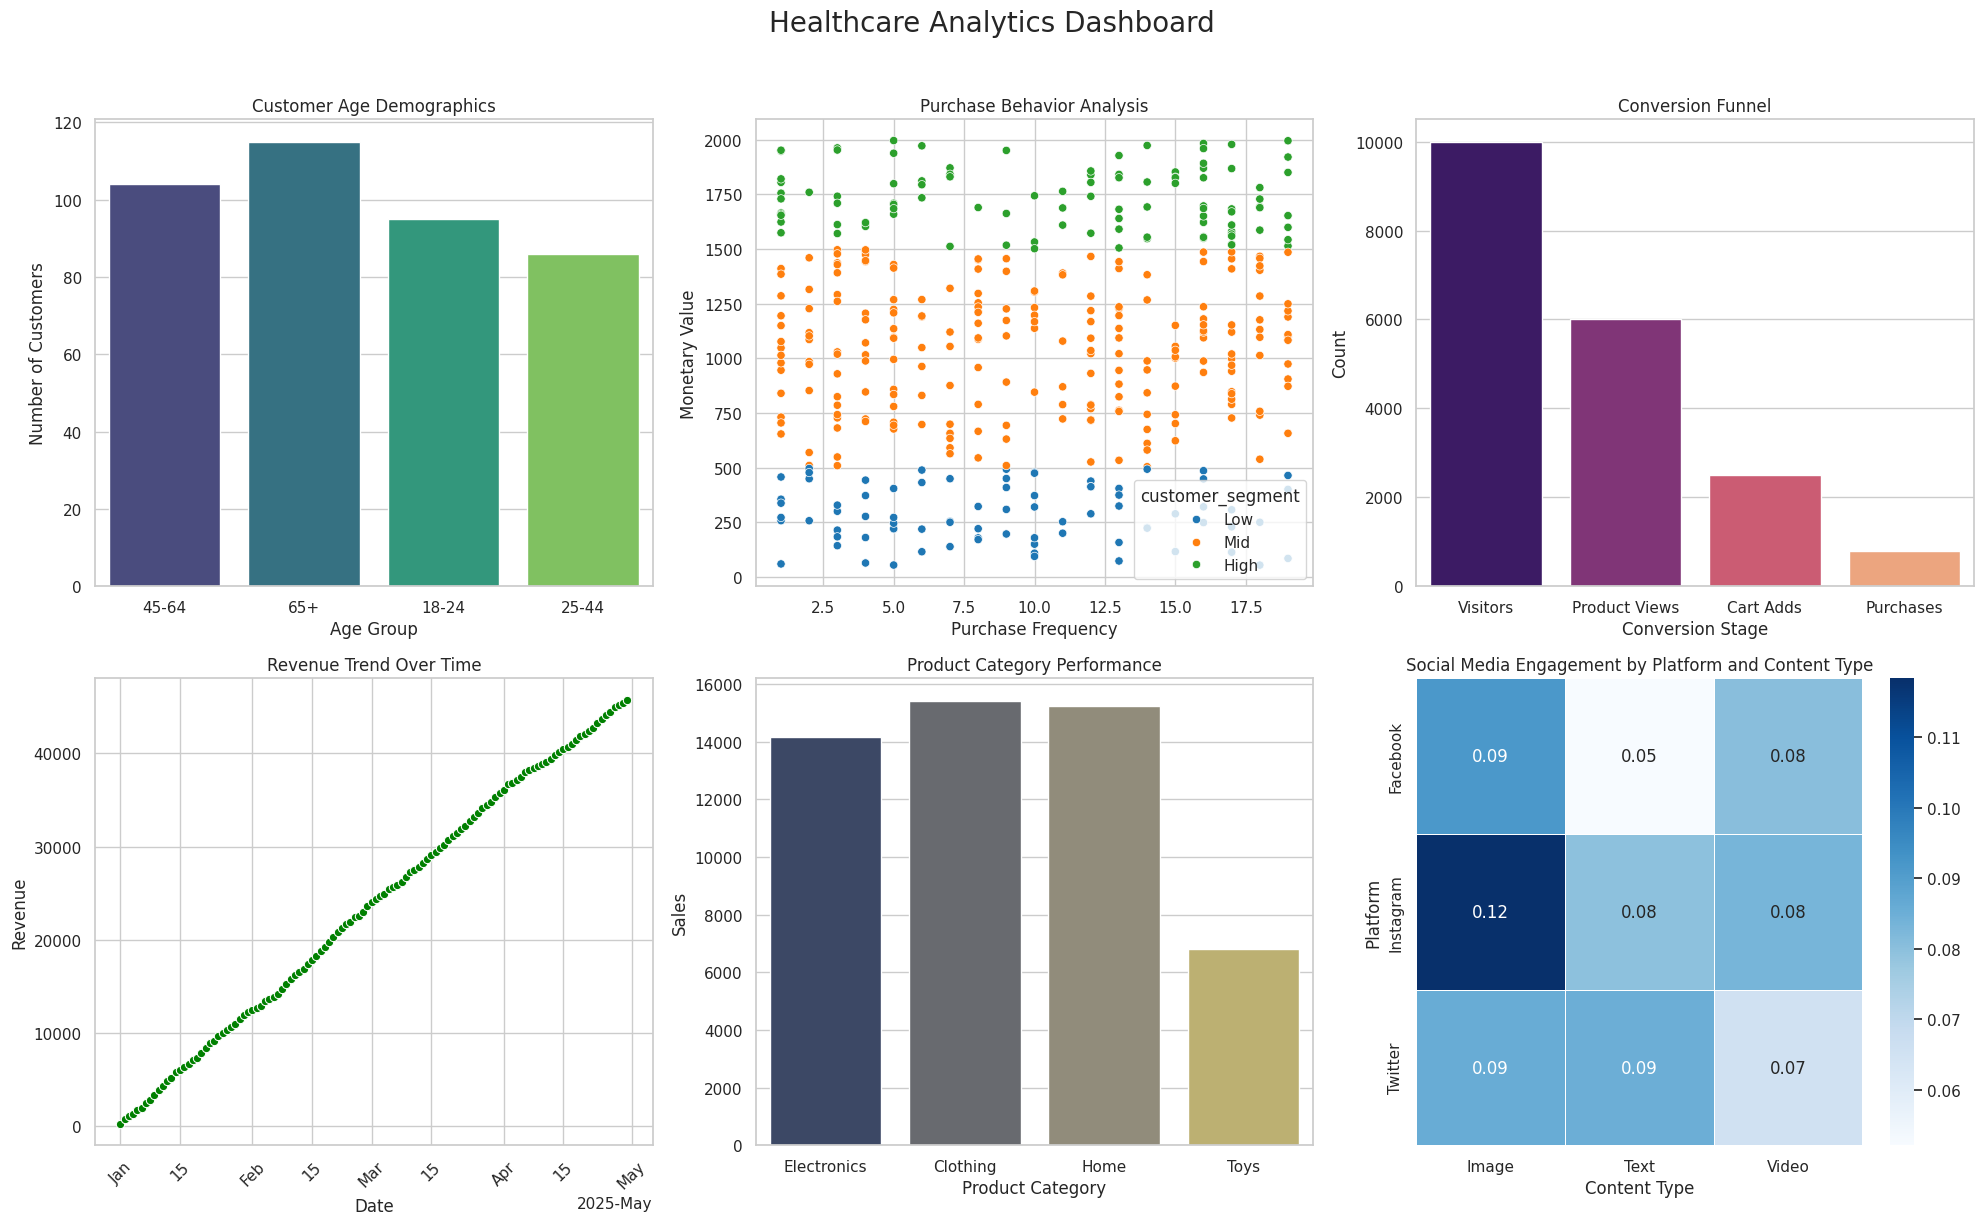

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Healthcare Analytics Dashboard', fontsize=20, y=1.02)

# 1. Customer Age Demographics
sns.countplot(x='age_group', data=customer_data, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Customer Age Demographics')
axes[0, 0].set_xlabel('Age Group')
axes[0, 0].set_ylabel('Number of Customers')

# 2. Purchase Behavior Analysis
sns.scatterplot(x='frequency', y='monetary_value', hue='customer_segment', data=customer_data, ax=axes[0, 1], palette='tab10')
axes[0, 1].set_title('Purchase Behavior Analysis')
axes[0, 1].set_xlabel('Purchase Frequency')
axes[0, 1].set_ylabel('Monetary Value')

# 3. Conversion Funnel
conversion_stages = pd.DataFrame({
    'Stage': ['Visitors', 'Product Views', 'Cart Adds', 'Purchases'],
    'Count': [10000, 6000, 2500, 800]
})
sns.barplot(x='Stage', y='Count', data=conversion_stages, ax=axes[0, 2], palette='magma')
axes[0, 2].set_title('Conversion Funnel')
axes[0, 2].set_xlabel('Conversion Stage')
axes[0, 2].set_ylabel('Count')

# 4. Revenue Trend
sns.lineplot(x='Date', y='Revenue', data=sales_data, ax=axes[1, 0], marker='o', color='green')
axes[1, 0].set_title('Revenue Trend Over Time')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Revenue')
# Format dates
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
axes[1, 0].xaxis.set_major_locator(locator)
axes[1, 0].xaxis.set_major_formatter(formatter)
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Category Performance
sns.barplot(x='Category', y='Sales', data=product_data, ax=axes[1, 1], palette='cividis')
axes[1, 1].set_title('Product Category Performance')
axes[1, 1].set_xlabel('Product Category')
axes[1, 1].set_ylabel('Sales')

# 6. Social Media Engagement
social_media_pivot = social_media_data.pivot_table(index='Platform', columns='Content_Type', values='Engagement_Rate', aggfunc='mean')
sns.heatmap(social_media_pivot, annot=True, cmap='Blues', fmt=".2f", linewidths=.5, ax=axes[1, 2])
axes[1, 2].set_title('Social Media Engagement by Platform and Content Type')
axes[1, 2].set_xlabel('Content Type')
axes[1, 2].set_ylabel('Platform')

# Final Touches
plt.tight_layout()
plt.show()